# BPS5231 Topic 16A — No-battery Baseline and PV-priority Control

This notebook reproduces the no-battery baseline, the first rule-based battery strategy and the Interim comparison for CityLearn 2022 `Building_5`.

The PV-priority controller charges only from simultaneous PV surplus and discharges only against simultaneous load deficit. It does not observe price, carbon intensity or future peaks. The battery equations are a transparent local reproduction of the relevant CityLearn v1.3.6 logic, not a claim that the complete CityLearn engine ran locally.

In [1]:
import io
import json
import os
import runpy
from contextlib import redirect_stdout
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/bps5231-matplotlib")

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

def locate_project(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "05_exploratory_data_analysis.py").exists() and (candidate / "data" / "processed" / "building_5_hourly_inputs.csv").exists():
            return candidate
    raise FileNotFoundError("Cannot locate the topic16a_interim project directory")

ROOT = locate_project(Path.cwd())
print(f"Project root: {ROOT}")

Project root: /Users/jh_skye/Documents/Codex/2026-09-24/2025-lectures/work/BPS5231/topic16a_interim


## 1. Reproduce the baseline and PV-priority strategy

In [2]:
for script in [
    "06_no_battery_baseline.py",
    "07_pv_priority_battery.py",
    "08_interim_comparative_analysis.py",
]:
    captured = io.StringIO()
    with redirect_stdout(captured):
        runpy.run_path(str(ROOT / script), run_name="__main__")
    print(f"Completed: {script}")

Completed: 06_no_battery_baseline.py
Completed: 07_pv_priority_battery.py
Completed: 08_interim_comparative_analysis.py


## 2. Annual KPI comparison

In [3]:
kpis = pd.read_csv(ROOT / "results" / "interim_comparison" / "annual_kpi_comparison.csv")
display(kpis[["metric", "unit", "no_battery", "pv_priority", "reported_improvement", "improvement_definition"]].style.format({
    "no_battery": "{:.4f}",
    "pv_priority": "{:.4f}",
    "reported_improvement": "{:.4f}",
}))

,metric,unit,no_battery,pv_priority,reported_improvement,improvement_definition
0,Grid import,kWh,4957.9506,3651.7741,26.3451,reduction from baseline (%)
1,Grid export,kWh,2217.9486,659.2197,70.2780,reduction from baseline (%)
2,Electricity cost,currency,1540.8814,1045.4165,32.1546,reduction from baseline (%)
3,Operational carbon,kgCO2,791.5337,573.9284,27.4916,reduction from baseline (%)
4,Peak grid import,kW,4.9388,4.9388,0.0000,reduction from baseline (%)
5,PV self-consumption,%,63.4463,89.1355,25.6892,percentage-point increase
6,Self-sufficiency,%,43.7085,58.5386,14.8300,percentage-point increase


## 3. Battery and comparison validation

In [4]:
checks_7 = pd.read_csv(ROOT / "results" / "pv_priority" / "validation_checks.csv")
checks_8 = pd.read_csv(ROOT / "results" / "interim_comparison" / "validation_checks.csv")
assert checks_7["passed"].all(), checks_7.loc[~checks_7["passed"]]
assert checks_8["passed"].all(), checks_8.loc[~checks_8["passed"]]

summary = json.loads((ROOT / "results" / "pv_priority" / "pv_priority_summary.json").read_text())
assert abs(summary["pv_priority"]["final_soc_kwh"] - summary["pv_priority"]["initial_soc_kwh"]) <= 1e-10
print(f"Step 7 checks passed: {checks_7['passed'].sum()}/{len(checks_7)}")
print(f"Step 8 checks passed: {checks_8['passed'].sum()}/{len(checks_8)}")
display(checks_8)

Step 7 checks passed: 15/15
Step 8 checks passed: 16/16


,check,passed,detail
0,Step 7 validation inherited,True,15 of 15 prior checks passed
1,8760 hourly records,True,n=8760
2,No missing comparison outputs,True,four primary comparison fields checked
3,Baseline import reconciles,True,hourly sum=4957.950569916 kWh
4,PV-priority import reconciles,True,hourly sum=3651.774050104 kWh
5,Cost saving identity,True,saving=495.464856030
6,Carbon reduction identity,True,reduction=217.605228332 kgCO2
7,Import reduction and discharge reconcile,True,difference=-0.000587833 kWh; within documented...
8,Export reduction and charge reconcile,True,difference=-0.000587833 kWh; within documented...
9,Monthly import reconciles,True,12 source-month groups


## 4. Diagnostic figures

01_representative_week.png


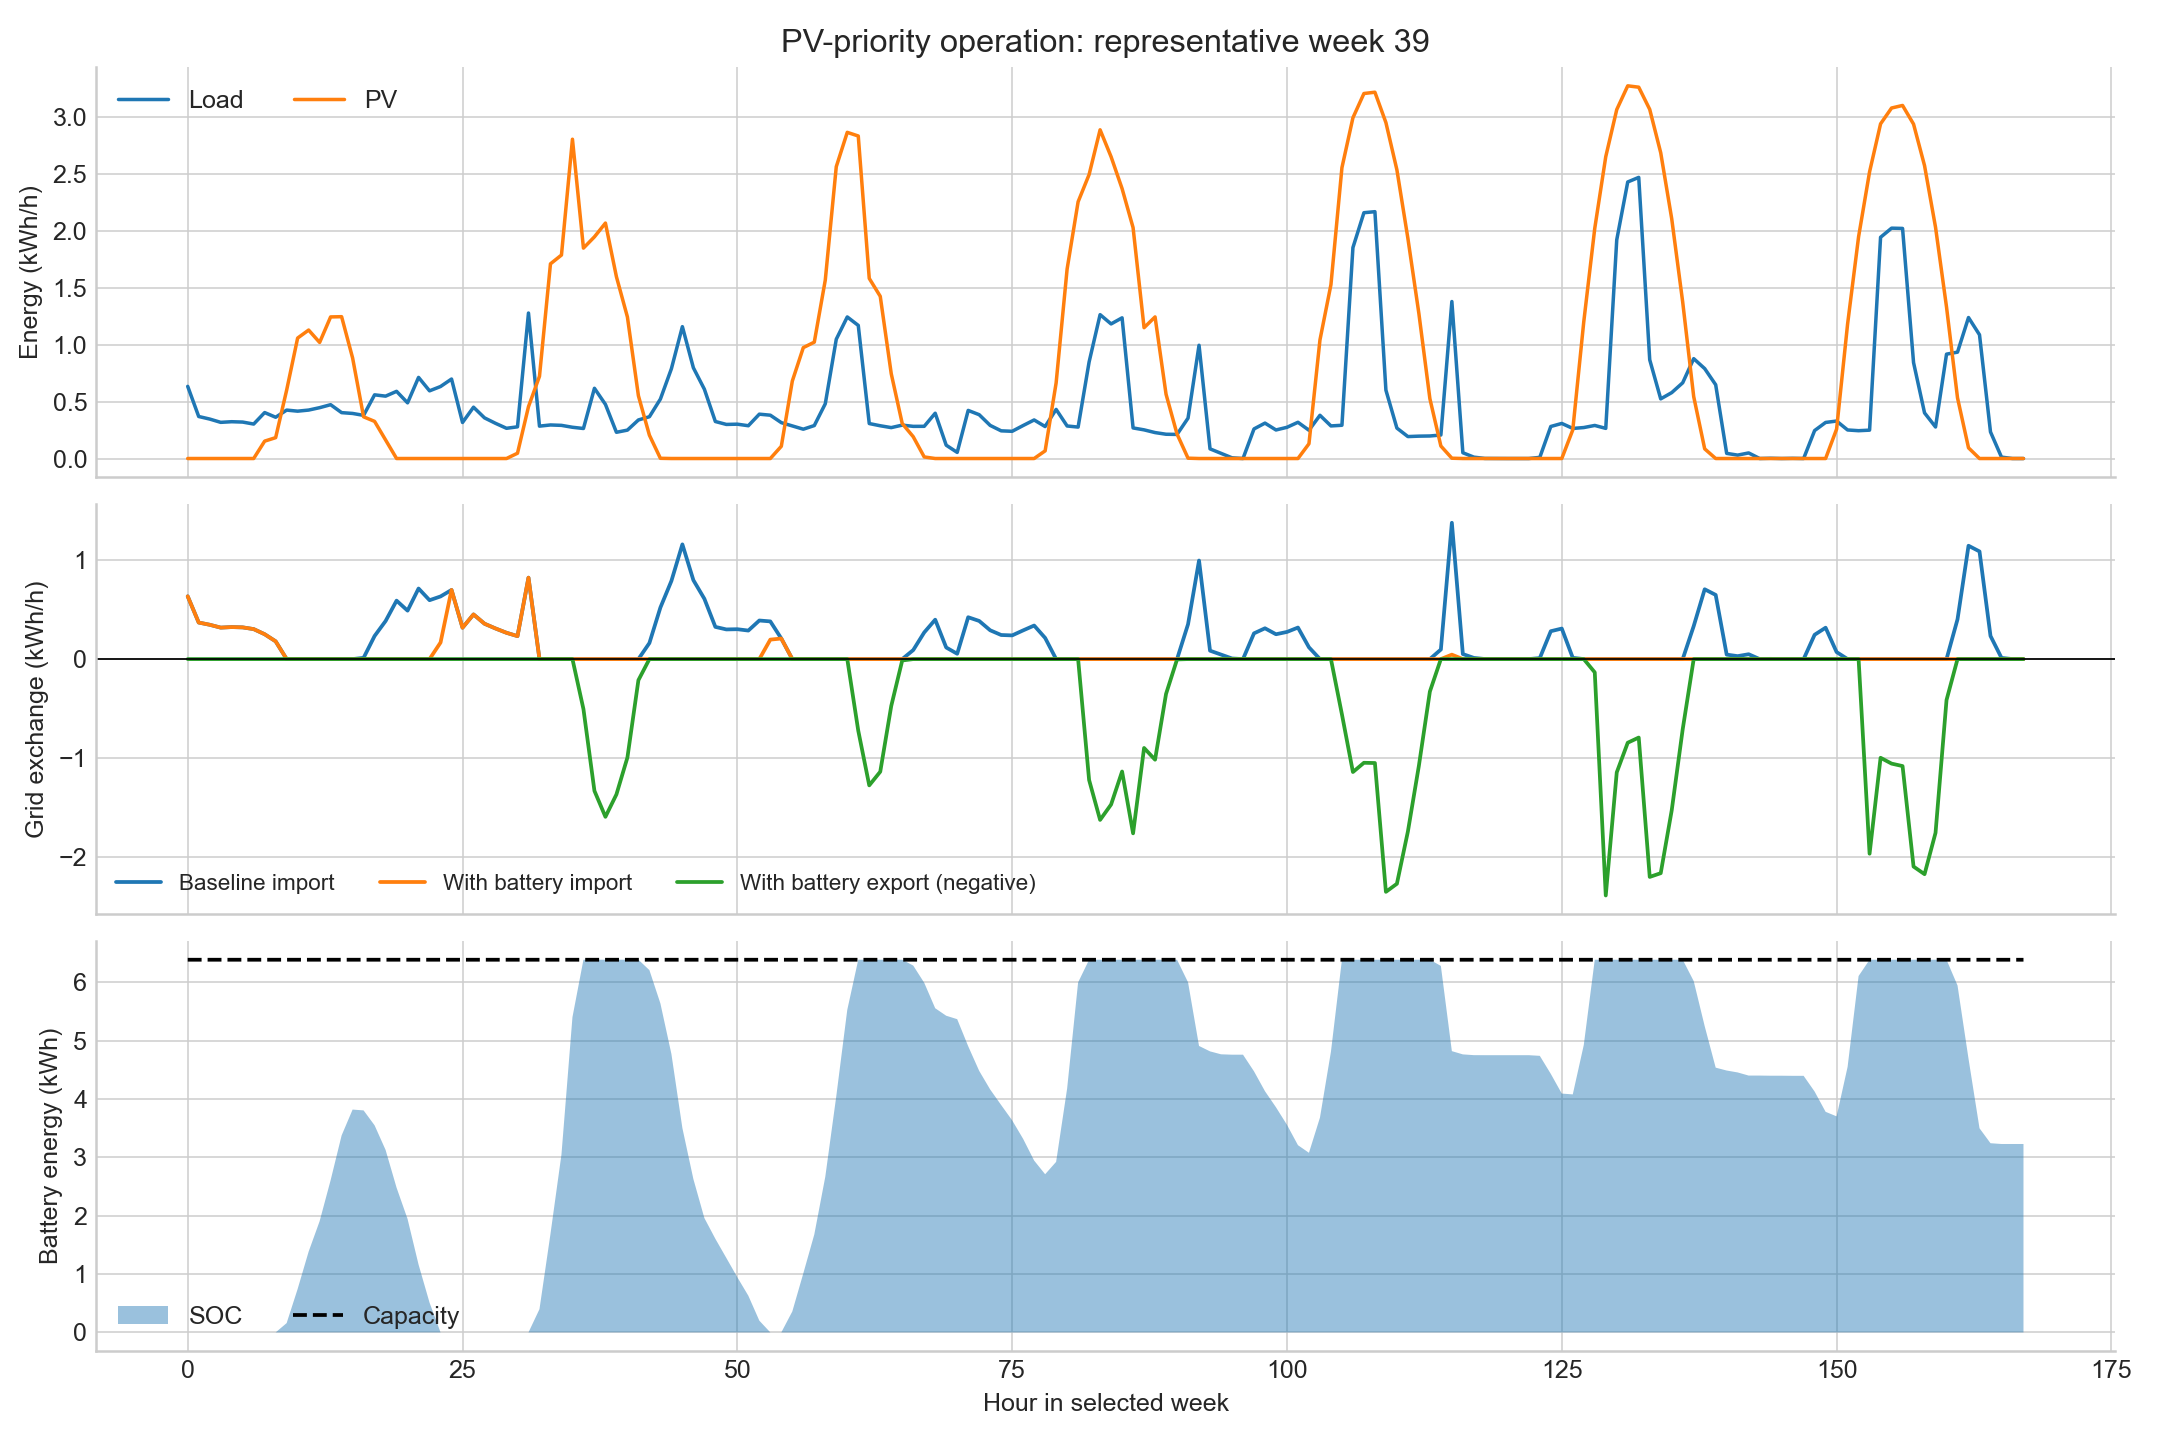

01_annual_kpi_comparison.png


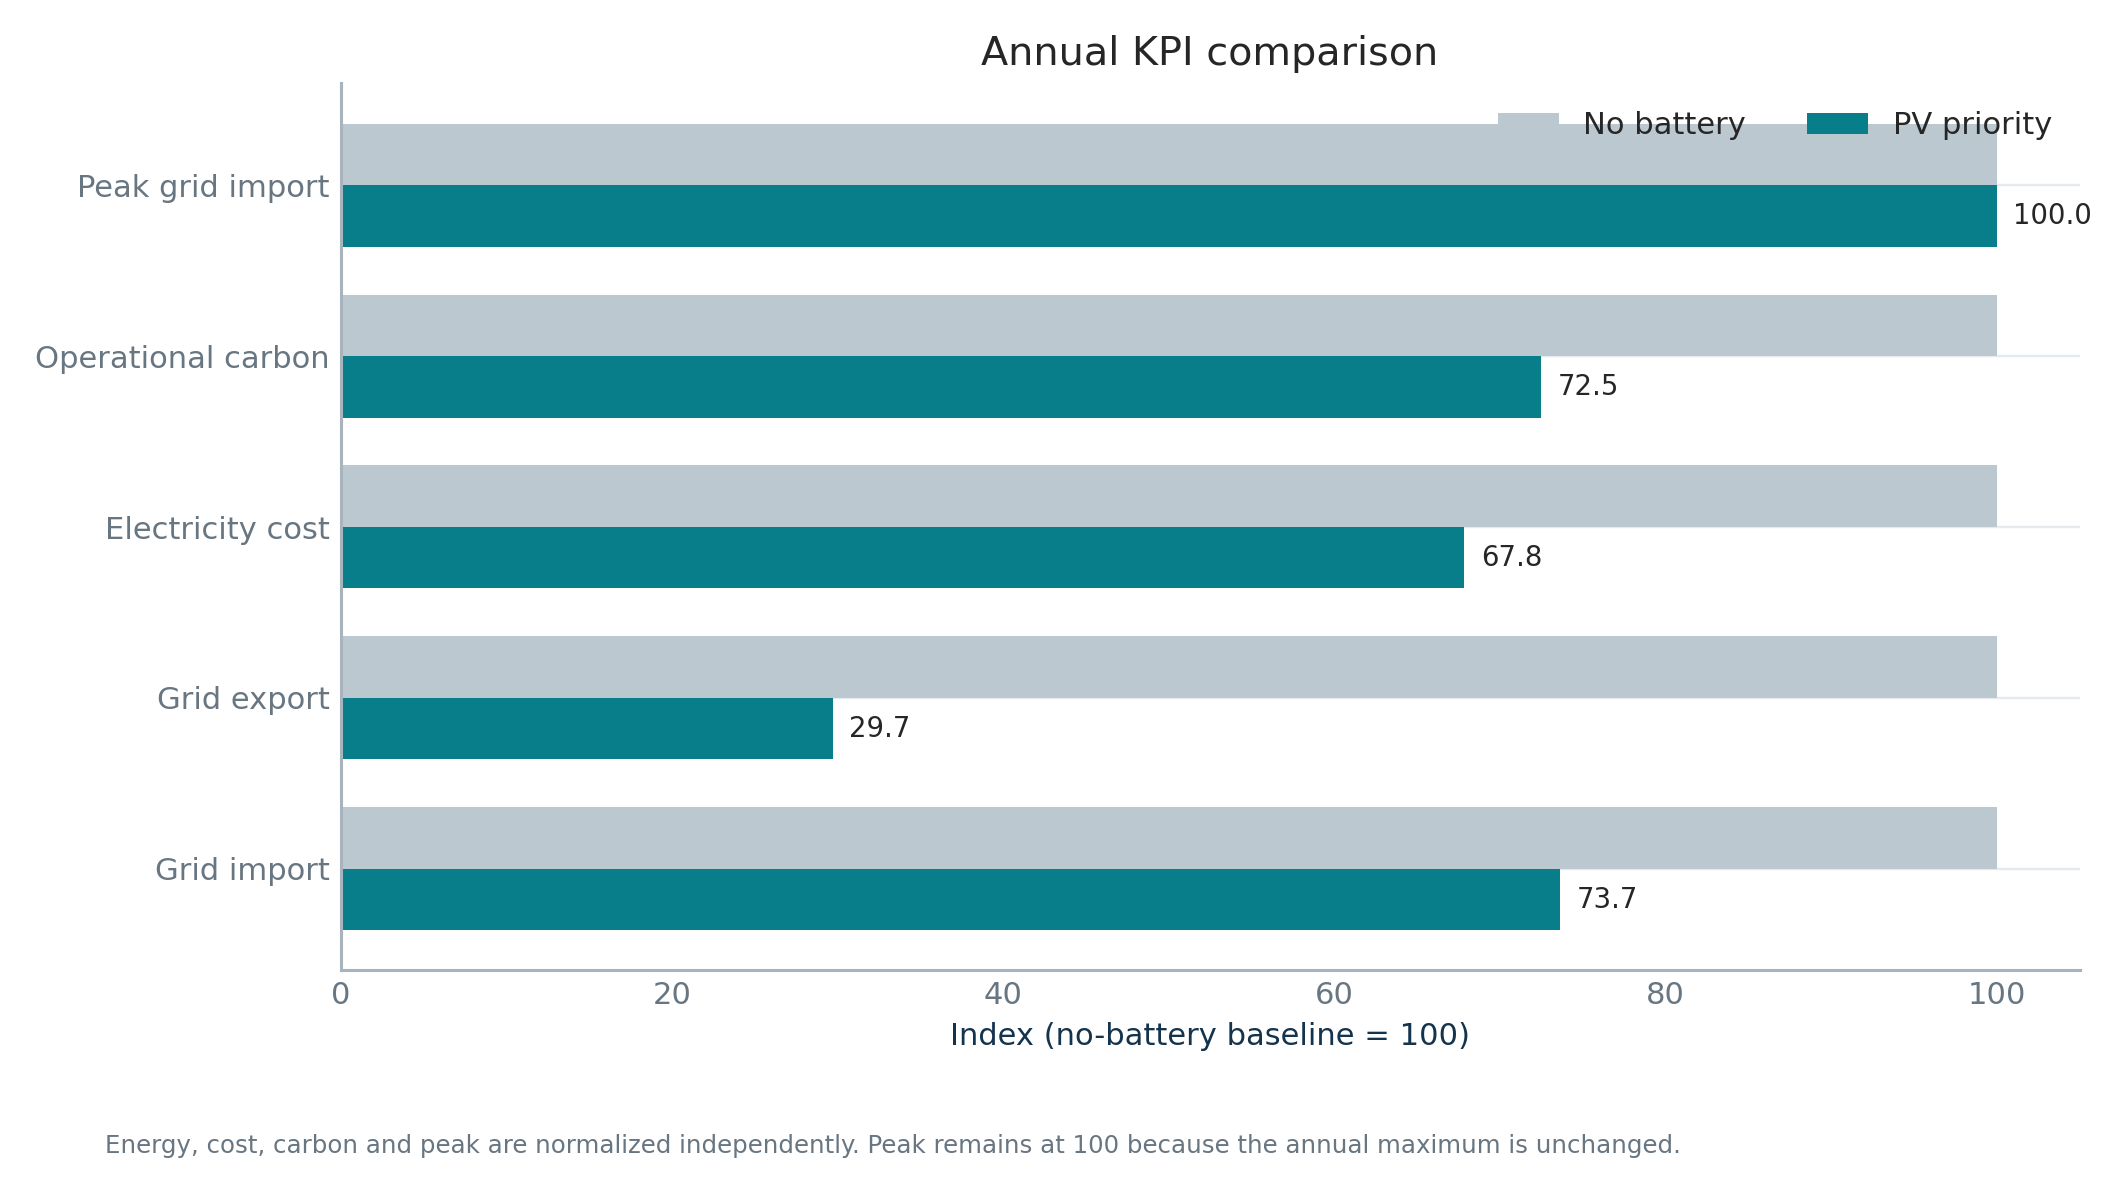

04_annual_peak_diagnostic.png


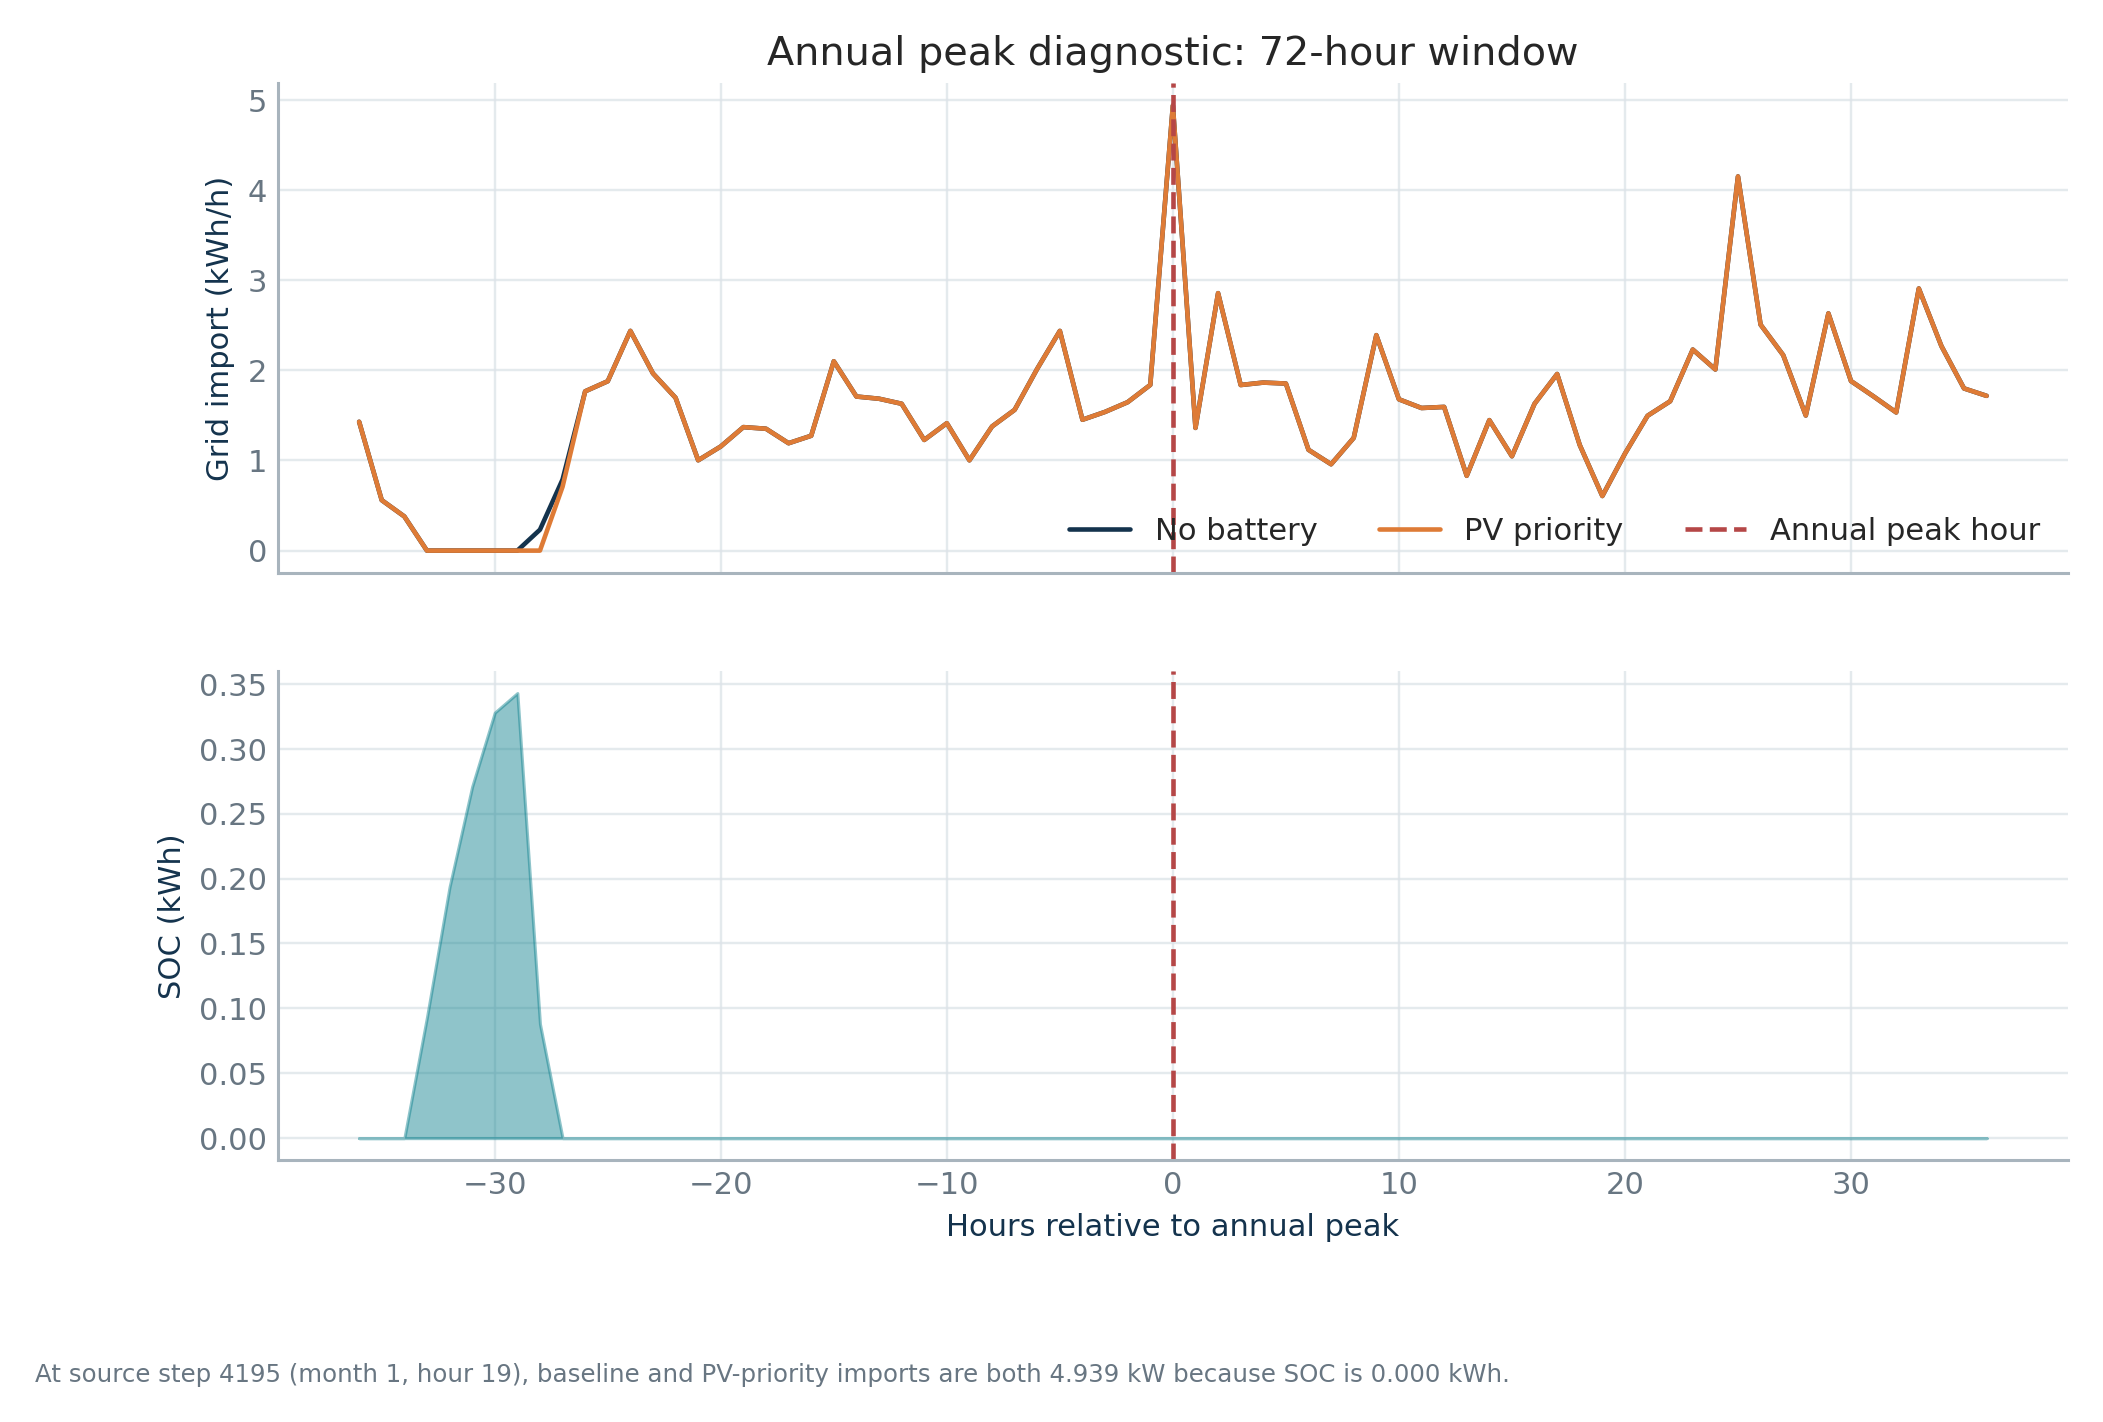

05_daily_peak_diagnostics.png


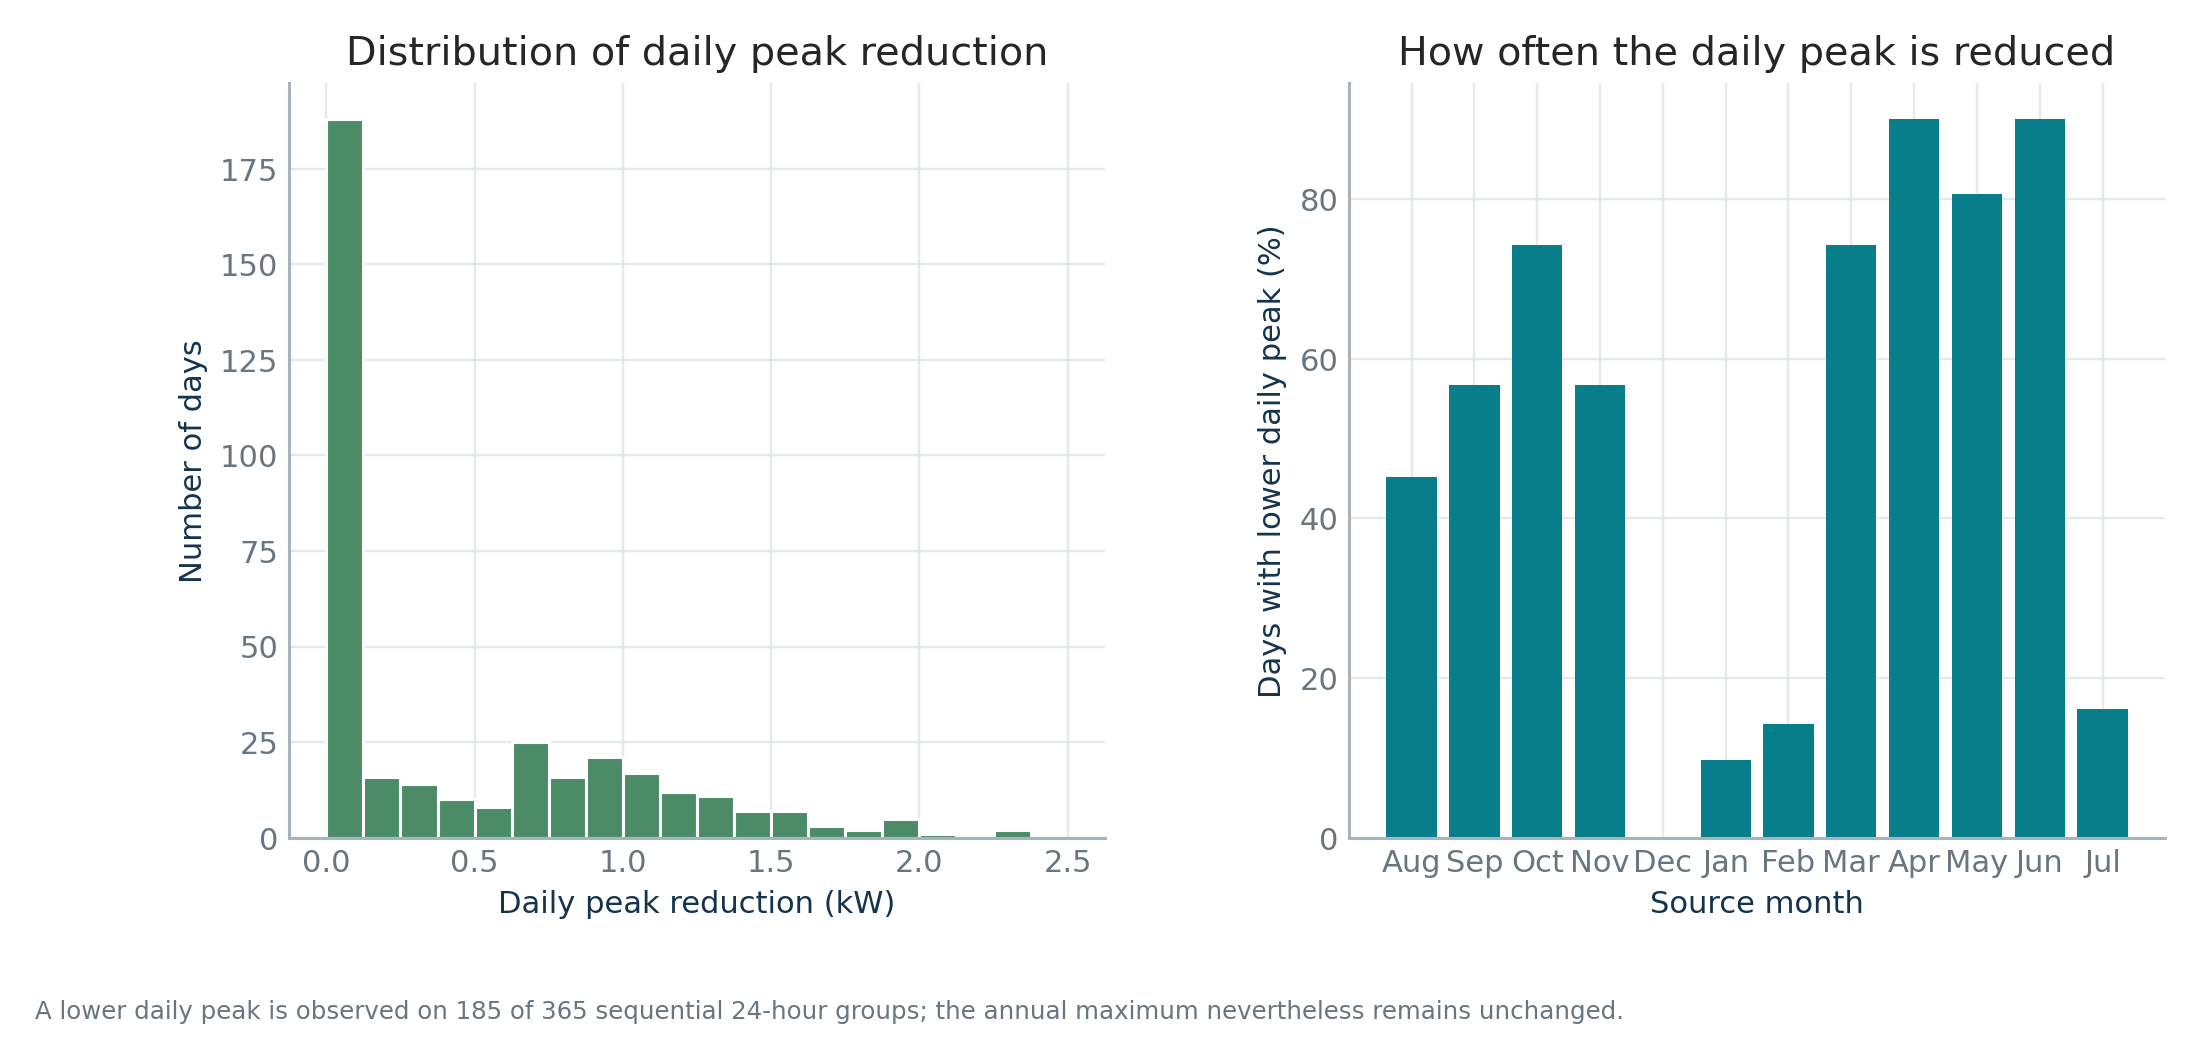

In [5]:
figure_paths = [
    ROOT / "figures" / "pv_priority" / "01_representative_week.png",
    ROOT / "figures" / "interim_comparison" / "01_annual_kpi_comparison.png",
    ROOT / "figures" / "interim_comparison" / "04_annual_peak_diagnostic.png",
    ROOT / "figures" / "interim_comparison" / "05_daily_peak_diagnostics.png",
]
for path in figure_paths:
    print(path.name)
    display(Image(filename=str(path), width=900))

## 5. Interim conclusion

PV-priority control reduces annual grid import from 4,957.95 to 3,651.77 kWh, import-only cost from 1,540.88 to 1,045.42 currency units, and imported operational carbon from 791.53 to 573.93 kgCO2. PV self-consumption rises from 63.45% to 89.14%.

The annual peak remains 4.939 kW. At source step 4195 the battery starts the peak hour empty, so it cannot reduce the maximum. The rule does reduce the daily peak on 185 of 365 sequential 24-hour groups, but that does not imply an annual-peak benefit.

These results establish a reproducible Interim baseline and one feasible control rule. They do not demonstrate cost optimality, carbon optimality or peak optimality. Step 9 defines the separate Final-stage controllers and Pareto evaluation needed for those claims.